# Night Light in the Lakefront Protection Zones

## What this notebook does
The Lakefront Protection Ordinance splits the lakefront into the **Offshore Zone** (the lake), the
**Public Use Zone** (parks, beaches, harbors) and the **Private Use Zone** (the buildings along the lake).

(`chicago_light_color_grid.ipynb` makes the four 100 m maps in `outputs/`)

## File inventory
The code lists the scene’s files and identifies their roles:
- LH images: 10 m panchromatic images—broadband brightness without separate RGB colors.
- RGB images: 40 m images with red, green, and blue measurements.
- Metadata XML: when and where the image was taken.
- Calibration XML: coefficients for converting raw numbers into radiance.
- Browse images and thumbnails: previews.
- Overviews: smaller versions that make large rasters faster to display.
The two cameras cover different parts of the scene. our check identifies camera B as covering Chicago.

# Setup

In [2]:
import os, sys
# technical fix so map projections work in this Python environment (safe to ignore)
os.environ["PROJ_DATA"] = os.environ["PROJ_LIB"] = os.path.join(sys.prefix, "share", "proj")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import xml.etree.ElementTree as ET
import rasterio
from rasterio import features
from rasterio.windows import from_bounds
from shapely.ops import unary_union

SCENE = "KX10_GIU_20250916_W89.00_N41.66_202500097282_L4A"
COLOR_FILE = f"{SCENE}/{SCENE}_B_RGB.tif"      # color image, 40 m
PAN_FILE = f"{SCENE}/{SCENE}_B_LH.tif"         # black-and-white image, 10 m (band 3 = HDR)
CALIB_FILE = f"{SCENE}/{SCENE}.calib.xml"
ZONE_FILE = "../Lakefront_zone/Master_LPO_Zones_031825.shp"
OUT_DIR = "outputs"
GRID_CRS = "EPSG:26916"                        # same map system as the 100 m grid

ZONES = ["Offshore Zone", "Public Use Zone", "Private Use Zone"]
ZONE_COLOR = {"Offshore Zone": "#e8e8e6", "Public Use Zone": "#1baf7a", "Private Use Zone": "#eb6834"}

## Read the zone map and confirm the resolution

I suspect that the targeted area can be narrow. So, let's check if the 100m grid is actually suitable.


In [3]:
zones = gpd.read_file(ZONE_FILE)
zones = zones.set_geometry(zones.geometry.force_2d()).set_crs("EPSG:4326", allow_override=True)
zones = zones.to_crs(GRID_CRS)[["Name", "geometry"]].set_index("Name").loc[ZONES].reset_index()

offshore = zones.geometry[zones.Name == "Offshore Zone"].iloc[0]
land_zones = unary_union(zones.geometry[zones.Name != "Offshore Zone"])

# the shoreline in the zone map = where the Offshore Zone touches the two land zones
shoreline = offshore.boundary.intersection(land_zones.buffer(1))

zones["area_km2"] = zones.area / 1e6
# average width of each land strip = area / length of shoreline
zones["avg_width_m"] = np.where(zones.Name == "Offshore Zone", np.nan, zones.area / shoreline.length)

zones.to_file(f"{OUT_DIR}/lakefront_zones_26916.gpkg")   # clean copy (2D, meters) for later joins
print(f"Shoreline length: {shoreline.length / 1000:.1f} km")
zones.drop(columns="geometry").round(1)

Shoreline length: 67.0 km


,Name,area_km2,avg_width_m
0,Offshore Zone,1063.0,NaN
1,Public Use Zone,13.7,203.9
2,Private Use Zone,8.8,130.7


the two land zones are only about **130-200 m wide** on average. The 100 m grid has just one or two
squares across them, so for numbers per zone we use the **40 m pixels** directly, we shouldn't use 100m grid.

## Check do the image and the zone map line up?
Lake Michigan is dark at night and the land next to it is lit. So the **edge between light and dark** in the image
should sit right on the shoreline of the zone map.

The method used to check: take a 300 m strip on each side of the shoreline. Measure how much brighter the land strip is than the water
strip. Then slide the image a little in every direction (up to 200 m) and measure again. If the image is placed
correctly, the difference is biggest when we don't move it at all.


In [4]:
def read_near_shore(path, band):
    # read the part of the image within 2 km of the shoreline
    with rasterio.open(path) as src:
        zones_utm = zones.to_crs(src.crs)
        shore_utm = gpd.GeoSeries([shoreline], crs=GRID_CRS).to_crs(src.crs).iloc[0]
        window = from_bounds(*shore_utm.buffer(2000).bounds, transform=src.transform).round_offsets().round_lengths()
        values = src.read(band, window=window).astype("float32")
        transform = src.window_transform(window)
    values[values == 0] = np.nan           # 0 = no data
    return values, transform, zones_utm, shore_utm

def shift_test(values, transform, zones_utm, shore_utm, max_shift=200, step=10, strip=300):
    # log scale, so a few very bright lamps don't decide the result
    log_light = np.log10(values)
    sea = zones_utm.geometry[zones_utm.Name == "Offshore Zone"].iloc[0]
    land = unary_union(zones_utm.geometry[zones_utm.Name != "Offshore Zone"])
    near = shore_utm.buffer(strip)
    land_strip = features.rasterize([near.intersection(land).difference(sea)], log_light.shape, transform=transform) == 1
    water_strip = features.rasterize([near.intersection(sea)], log_light.shape, transform=transform) == 1

    pixel = transform.a
    shifts = np.arange(-max_shift, max_shift + 1, step)
    contrast = np.full((len(shifts), len(shifts)), np.nan)
    for i, dy in enumerate(shifts):          # dy > 0: image moved north
        for j, dx in enumerate(shifts):      # dx > 0: image moved east
            moved = np.roll(log_light, (-int(dy / pixel), int(dx / pixel)), axis=(0, 1))
            contrast[i, j] = np.nanmean(moved[land_strip]) - np.nanmean(moved[water_strip])
    i, j = np.unravel_index(np.nanargmax(contrast), contrast.shape)
    return shifts, contrast, shifts[j], shifts[i]

# 10 m black-and-white image (HDR band)
pan, pan_tf, zones_utm, shore_utm = read_near_shore(PAN_FILE, 3)
# 40 m color image (green band), split into 10 m pieces
green, green_tf, _, _ = read_near_shore(COLOR_FILE, 2)
green_10m = np.kron(green, np.ones((4, 4), dtype="float32"))
green_10m_tf = green_tf * rasterio.Affine.scale(0.25)

results = {}
for name, values, tf in [("10 m black-and-white", pan, pan_tf), ("40 m color", green_10m, green_10m_tf)]:
    shifts, contrast, best_dx, best_dy = shift_test(values, tf, zones_utm, shore_utm)
    results[name] = (shifts, contrast)
    print(f"{name:22s} best fit when the image is moved {best_dx:+d} m east, {best_dy:+d} m north")

10 m black-and-white   best fit when the image is moved +0 m east, +10 m north
40 m color             best fit when the image is moved -40 m east, +0 m north


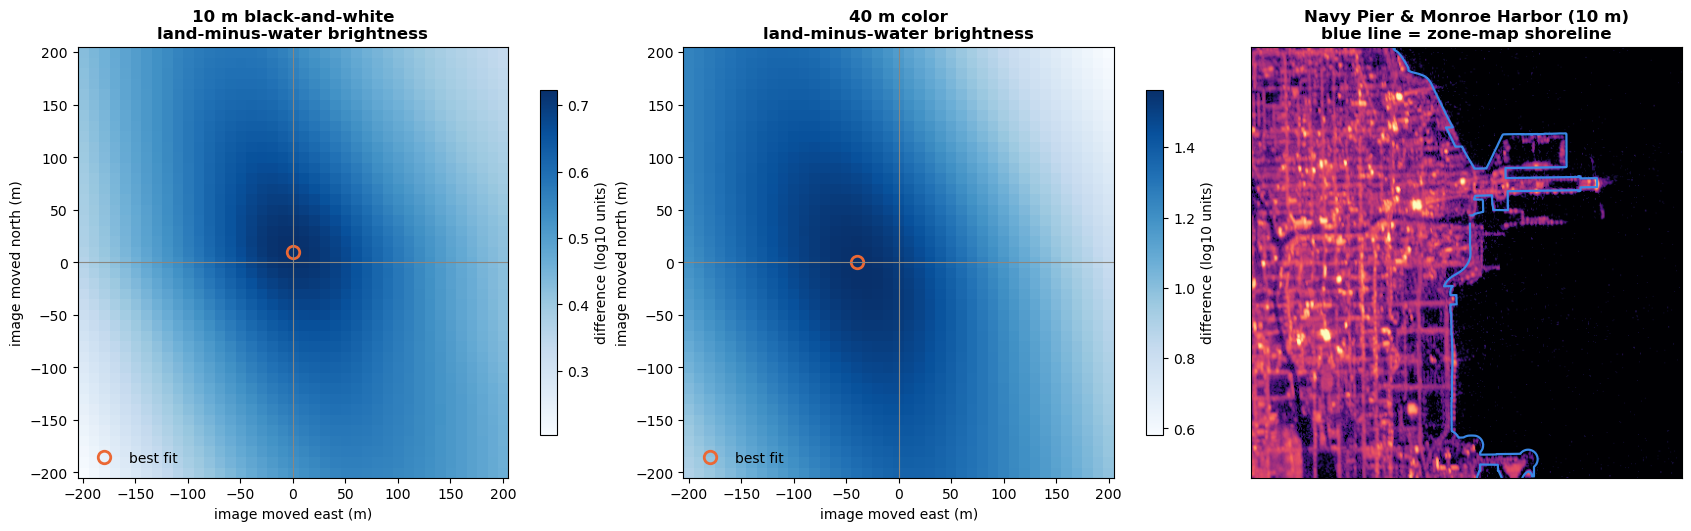

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.2), layout="constrained")

for ax, (name, (shifts, contrast)) in zip(axes[:2], results.items()):
    im = ax.imshow(contrast, origin="lower", cmap="Blues",
                   extent=[shifts[0] - 5, shifts[-1] + 5, shifts[0] - 5, shifts[-1] + 5])
    i, j = np.unravel_index(np.nanargmax(contrast), contrast.shape)
    ax.plot(shifts[j], shifts[i], "o", ms=9, mfc="none", mec="#eb6834", mew=2, label="best fit")
    ax.axhline(0, color="#898781", lw=0.8); ax.axvline(0, color="#898781", lw=0.8)
    ax.set_title(f"{name}\nland-minus-water brightness", fontweight="bold")
    ax.set_xlabel("image moved east (m)"); ax.set_ylabel("image moved north (m)")
    ax.legend(loc="lower left", frameon=False)
    plt.colorbar(im, ax=ax, shrink=0.8, label="difference (log10 units)")

# close-up: Navy Pier and Monroe Harbor, 10 m image with the zone shoreline on top
ax = axes[2]
navy_pier = gpd.GeoSeries.from_xy([-87.6050], [41.8917], crs="EPSG:4326").to_crs(zones_utm.crs).iloc[0]
cx, cy, half = navy_pier.x - 800, navy_pier.y - 800, 2200
left, top = pan_tf.c, pan_tf.f
r0, r1 = int((top - (cy + half)) / 10), int((top - (cy - half)) / 10)
c0, c1 = int((cx - half - left) / 10), int((cx + half - left) / 10)
ax.imshow(np.log10(pan[r0:r1, c0:c1]), cmap="magma", extent=[cx - half, cx + half, cy - half, cy + half])
gpd.GeoSeries([shore_utm]).plot(ax=ax, color="#3987e5", lw=1.6)
ax.set_xlim(cx - half, cx + half); ax.set_ylim(cy - half, cy + half)
ax.set_title("Navy Pier & Monroe Harbor (10 m)\nblue line = zone-map shoreline", fontweight="bold")
ax.set_xticks([]); ax.set_yticks([])

fig.savefig("figures/11_shoreline_alignment.png", dpi=150, bbox_inches="tight")
plt.show()

The difference seems acceptable.

## Look at the light maps with the zones on top
Left: the whole study area. Right: the four maps zoomed to the lakefront.

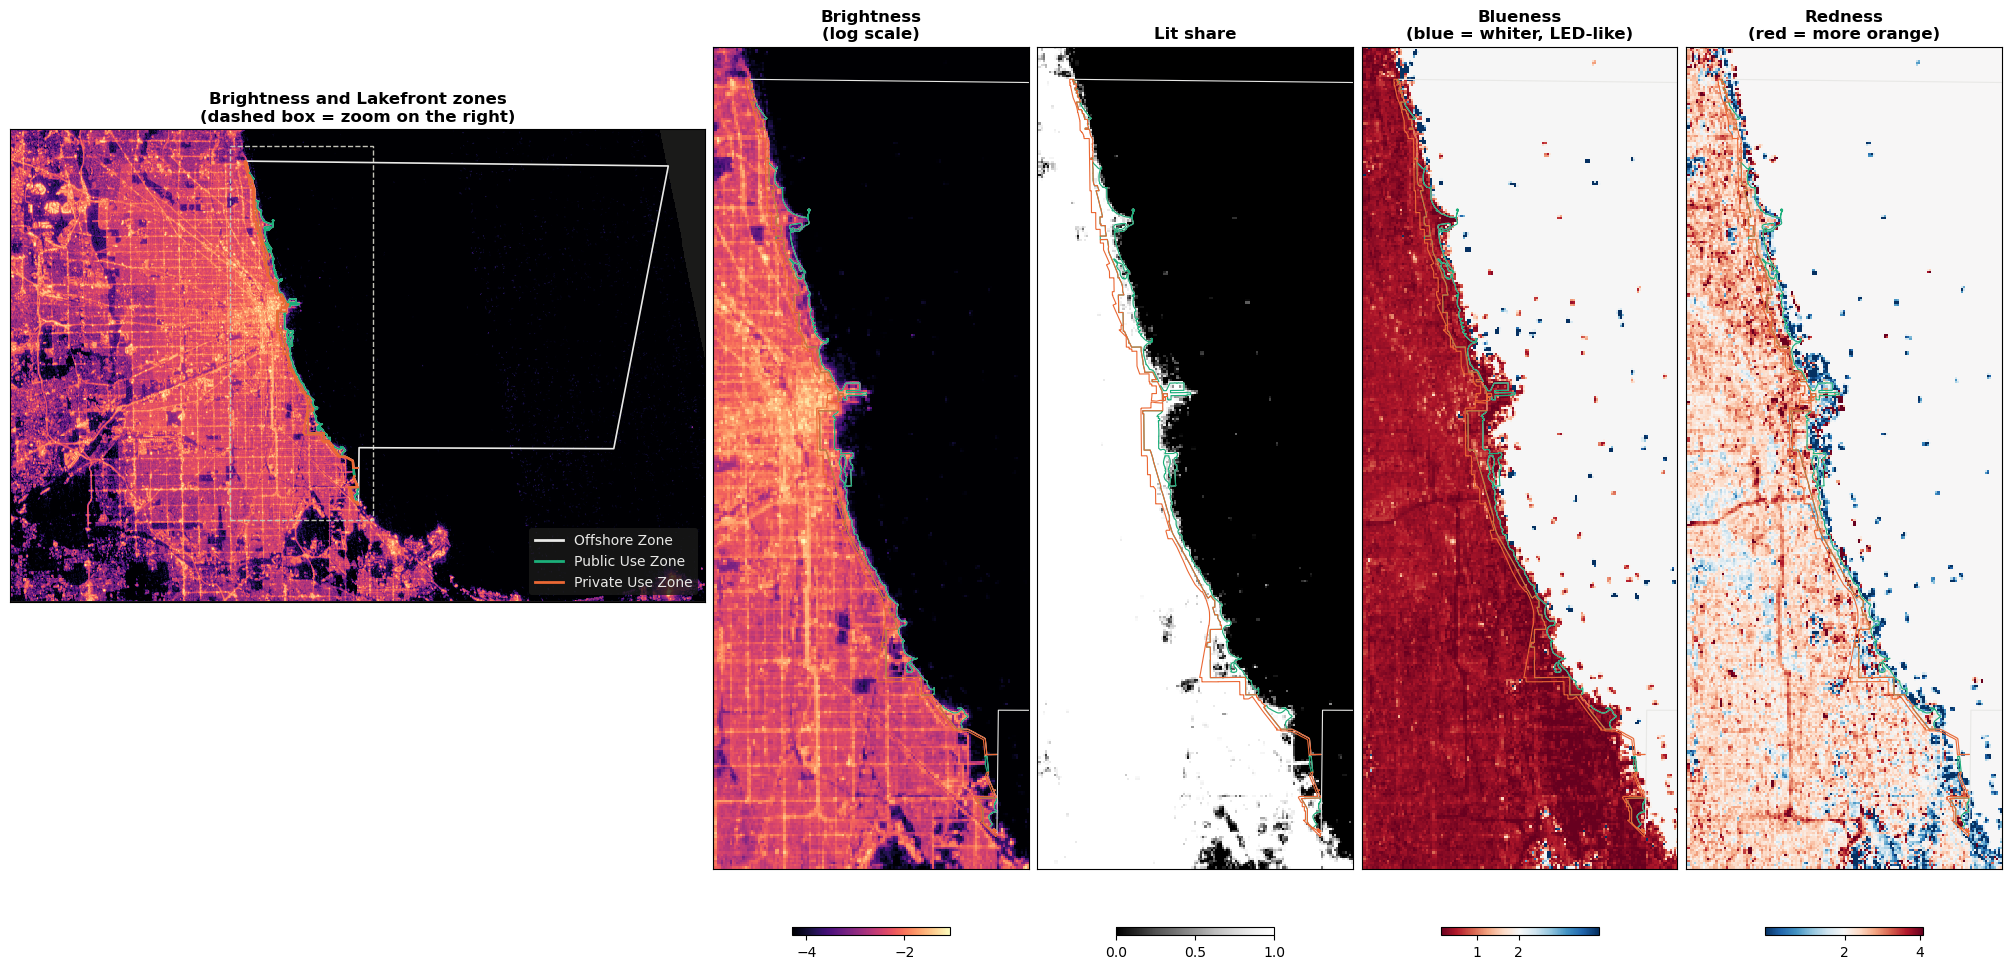

In [6]:
maps = {}
for name in ["brightness", "lit_share", "blueness", "redness"]:
    with rasterio.open(f"{OUT_DIR}/light_{name}_100m.tif") as src:
        maps[name] = src.read(1)
        grid_tf, grid_shape = src.transform, src.shape
grid_extent = [grid_tf.c, grid_tf.c + grid_tf.a * grid_shape[1], grid_tf.f + grid_tf.e * grid_shape[0], grid_tf.f]

def centered_on_median(m):
    # same color scale as in chicago_light_color_grid.ipynb
    v = m[np.isfinite(m)]
    low, mid, high = np.percentile(v, [2, 50, 98])
    return plt.matplotlib.colors.TwoSlopeNorm(vmin=low, vcenter=mid, vmax=high)

panels = [
    ("brightness", "Brightness\n(log scale)", "magma", None),
    ("lit_share", "Lit share", "Greys_r", None),
    ("blueness", "Blueness\n(blue = whiter, LED-like)", "RdBu", centered_on_median(maps["blueness"])),
    ("redness", "Redness\n(red = more orange)", "RdBu_r", centered_on_median(maps["redness"])),
]

def draw_zones(ax, lw=1.0):
    for _, z in zones.iterrows():
        gpd.GeoSeries([z.geometry]).boundary.plot(ax=ax, color=ZONE_COLOR[z.Name], lw=lw)

zone_legend = [Line2D([], [], color=ZONE_COLOR[n], lw=2, label=n) for n in ZONES]
lake_x0, lake_y0, lake_x1, lake_y1 = land_zones.buffer(1500).bounds

fig = plt.figure(figsize=(20, 11), layout="constrained")
grid = fig.add_gridspec(1, 5, width_ratios=[2.2, 1, 1, 1, 1])

ax = fig.add_subplot(grid[0])
ax.set_facecolor("#1a1a19")
ax.imshow(maps["brightness"], extent=grid_extent, cmap="magma", interpolation="nearest")
draw_zones(ax, lw=1.2)
ax.add_patch(plt.Rectangle((lake_x0, lake_y0), lake_x1 - lake_x0, lake_y1 - lake_y0,
                           fill=False, ec="#c3c2b7", ls="--", lw=1))
ax.set_title("Brightness and Lakefront zones\n(dashed box = zoom on the right)", fontweight="bold")
ax.set_xticks([]); ax.set_yticks([])
ax.legend(handles=zone_legend, loc="lower right", facecolor="#1a1a19", labelcolor="#e8e8e6", edgecolor="none")

for k, (name, title, cmap, norm) in enumerate(panels):
    ax = fig.add_subplot(grid[k + 1])
    ax.set_facecolor("#1a1a19")
    im = ax.imshow(maps[name], extent=grid_extent, cmap=cmap, norm=norm, interpolation="nearest")
    draw_zones(ax, lw=0.8)
    ax.set_xlim(lake_x0, lake_x1); ax.set_ylim(lake_y0, lake_y1)
    ax.set_title(title, fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, shrink=0.5, location="bottom")

fig.savefig("figures/12_lakefront_zone_maps.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 4. Light in each zone
We use the **40 m color pixels** whose center falls inside each zone, with the same rules:
- a pixel is **lit** if green is at least 20
- its color is **usable** if it is lit and not a moving light
- zone **blueness** = total blue / total green over usable pixels (and **redness** the same with red)

**Brightness** here is the average light per pixel (red + green + blue radiance), so big and small zones can be compared.

In [7]:
with open(CALIB_FILE, encoding="gb2312") as f:
    calib = ET.fromstring(f.read()).find(".//GIU")

def gain_bias(color):
    return (float(calib.findtext(f".//RADIANCE_GAIN_BAND_{color}")),
            float(calib.findtext(f".//RADIANCE_BIAS_BAND_{color}")))

# read the color image over the zones only
with rasterio.open(COLOR_FILE) as src:
    zones_img = zones.to_crs(src.crs)
    window = from_bounds(*zones_img.total_bounds, transform=src.transform).round_offsets().round_lengths()
    raw = src.read(window=window).astype("float32")
    img_tf = src.window_transform(window)

inside_photo = (raw > 0).all(axis=0)
red, green, blue = [np.where(inside_photo, raw[i] * g + b, np.nan)
                    for i, (g, b) in enumerate(map(gain_bias, ["RED", "GREEN", "BLUE"]))]

is_lit = inside_photo & (raw[1] >= 20)
is_maxed_out = (raw >= 4095).any(axis=0)
with np.errstate(divide="ignore", invalid="ignore"):
    blueness_px, redness_px = blue / green, red / green

# moving-light cutoffs: same 0.1% / 99.9% rule as the grid notebook, taken over this image area
is_weird = np.zeros_like(is_lit)
for ratio in [blueness_px, redness_px]:
    low, high = np.percentile(ratio[is_lit & ~is_maxed_out], [0.1, 99.9])
    is_weird |= (ratio < low) | (ratio > high)
usable = is_lit & ~is_maxed_out & ~is_weird

rows = []
for _, z in zones_img.iterrows():
    in_zone = features.rasterize([z.geometry], raw.shape[1:], transform=img_tf) == 1
    px = in_zone & inside_photo
    u = px & usable
    rows.append({
        "zone": z.Name,
        "pixels (40 m)": int(px.sum()),
        "lit share": is_lit[px].mean(),
        "avg brightness": np.nanmean((red + green + blue)[px]),
        "blueness": blue[u].sum() / green[u].sum() if u.any() else np.nan,
        "redness": red[u].sum() / green[u].sum() if u.any() else np.nan,
        "usable color pixels": int(u.sum()),
    })

zone_light = pd.DataFrame(rows).set_index("zone")
zone_light.to_csv(f"{OUT_DIR}/lakefront_zone_light_summary.csv")
zone_light.round(3)

,pixels (40 m),lit share,avg brightness,blueness,redness,usable color pixels
zone,,,,,,
Offshore Zone,664258,0.004,0.000,0.328,1.772,2790
Public Use Zone,8627,0.890,0.006,0.397,2.381,7571
Private Use Zone,5421,0.958,0.008,0.434,2.451,5165


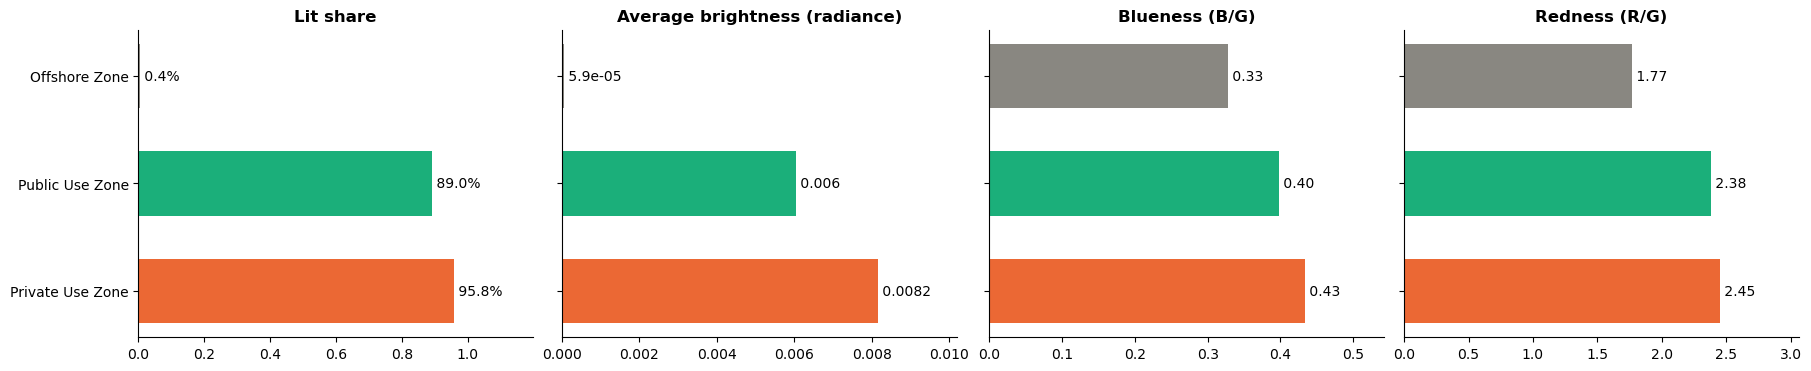

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(18, 3.6), layout="constrained")
measures = [("lit share", "Lit share", "{:.1%}"), ("avg brightness", "Average brightness (radiance)", "{:.2g}"),
            ("blueness", "Blueness (B/G)", "{:.2f}"), ("redness", "Redness (R/G)", "{:.2f}")]
for ax, (col, title, fmt) in zip(axes, measures):
    vals = zone_light[col]
    bars = ax.barh(vals.index, vals.values, color=[ZONE_COLOR[n] if n != "Offshore Zone" else "#898781"
                                                   for n in vals.index], height=0.6)
    for b, v in zip(bars, vals.values):
        if np.isfinite(v):
            ax.text(b.get_width(), b.get_y() + b.get_height() / 2, " " + fmt.format(v), va="center", fontsize=10)
    ax.set_title(title, fontweight="bold")
    ax.invert_yaxis()
    ax.spines[["top", "right"]].set_visible(False)
    ax.margins(x=0.25)
    if ax is not axes[0]:
        ax.set_yticklabels([])
fig.savefig("figures/13_zone_light_summary.png", dpi=150, bbox_inches="tight")
plt.show()

**How to read this** (city-wide values from the grid notebook: blueness about **0.39** typical square, **0.456**
light-weighted; redness about **2.2**):
- The **Offshore Zone** is almost all dark water. Its few lit pixels are piers, harbors, boats and light spilling
  from the shore, so its color numbers rest on very few pixels and should not be over-read.
- **Private Use Zone** (high-rises along the lake) is the brightest and most fully lit (96% of pixels lit), with the
  bluest light of the three zones (0.43).
- **Public Use Zone** (parks, beaches, harbors) is about 25% dimmer, 89% lit, and a bit less blue (0.40).
- Both lakefront zones are **less blue than the city as a whole** (0.456, light-weighted), so the lakefront is not
  more LED-heavy than the rest of Chicago on this night.
- The two zones sit side by side, so their differences are about what is built there, not about which part of
  the city they are in. With one night of data, these are descriptions, not tested differences.

## What this means for the project
- The light maps and the ordinance zones **line up** (10 m image: no shift; 40 m color image: at most one pixel), so we can compare light between
  zones without moving the image.
- The 100 m grid now also covers the whole Offshore Zone (it used to stop about 30 km short of its east edge).
- We now have the **first numbers for light in the Public vs. Private Use Zones**, saved in
  `outputs/lakefront_zone_light_summary.csv`.

(Still **one night** (Sept 15, 2025, about 9:30 pm). One night can't show changes over the season or the year)

**Possible next step (bonus):** daily night light from NASA Black Marble (VNP46A2, about 500 m pixels) could show
changes from night to night. Those pixels are wider than the land zones, so they work for the lakefront as a whole
or the Offshore Zone, not for Public vs. Private.